In [2]:
pip install transformers datasets evaluate accelerate gradio

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

import evaluate

from sklearn.metrics import accuracy_score, f1_score

import gradio as gr

C:\Users\HP\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch Version: 2.13.0+cpu
CUDA Available: False
Running on CPU


# News Topic Classification Using BERT

## Objective

The objective of this project is to fine-tune the **bert-base-uncased** transformer model for classifying news headlines into their respective topic categories using the AG News dataset.

The model is evaluated using **Accuracy** and **F1-score**. A Gradio interface is developed for real-time news topic prediction.

In [5]:
from datasets import load_dataset

ds = load_dataset("SetFit/ag_news")

Generating test split: 100%|████████████████████████████████████████████| 7600/7600 [00:00<00:00, 230512.93 examples/s]


In [7]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 7600
    })
})

In [8]:
ds["train"][0]

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.",
 'label': 2,
 'label_text': 'Business'}

In [9]:
ds["train"][:5]

{'text': ["Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.",
  'Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\\which has a reputation for making well-timed and occasionally\\controversial plays in the defense industry, has quietly placed\\its bets on another part of the market.',
  "Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\\about the economy and the outlook for earnings are expected to\\hang over the stock market next week during the depth of the\\summer doldrums.",
  'Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\\flows from the main pipeline in southern Iraq after\\intelligence showed a rebel militia could strike\\infrastructure, an oil official said on Saturday.',
  'Oil prices soar to all-time record, posing new menace to 

In [10]:
train_df = ds["train"].to_pandas()
test_df = ds["test"].to_pandas()

In [11]:
train_df.head()

,text,label,label_text
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


In [12]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   text        120000 non-null  object
 1   label       120000 non-null  int64 
 2   label_text  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


In [13]:
train_df.isnull().sum()

text          0
label         0
label_text    0
dtype: int64

In [14]:
train_df.duplicated().sum()

np.int64(0)

In [15]:
train_df["label"].value_counts()

label
2    30000
3    30000
1    30000
0    30000
Name: count, dtype: int64

In [16]:
label_names = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

In [17]:
train_df["category"] = train_df["label"].map(label_names)

In [18]:
train_df.head()

,text,label,label_text,category
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business,Business
4,"Oil prices soar to all-time record, posing new...",2,Business,Business


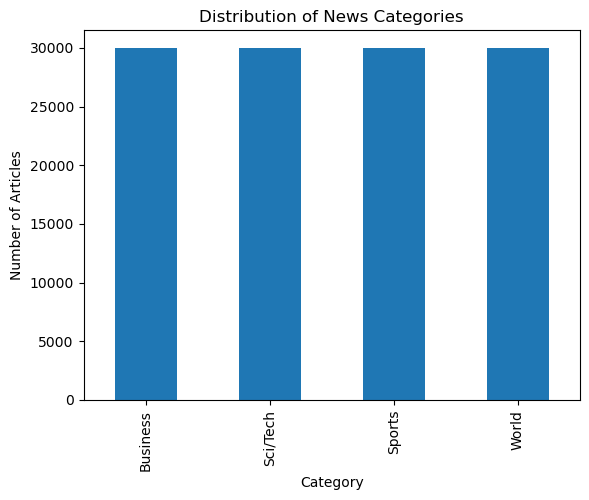

In [19]:
import matplotlib.pyplot as plt

train_df["category"].value_counts().plot(kind="bar")

plt.title("Distribution of News Categories")
plt.xlabel("Category")
plt.ylabel("Number of Articles")

plt.show()

In [20]:
small_train = ds["train"].shuffle(seed=42).select(range(5000))
small_test = ds["test"].shuffle(seed=42).select(range(1000))

In [21]:
print(small_train)
print(small_test)

Dataset({
    features: ['text', 'label', 'label_text'],
    num_rows: 5000
})
Dataset({
    features: ['text', 'label', 'label_text'],
    num_rows: 1000
})


In [22]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [23]:
sample_text = small_train[0]["text"]

print(sample_text)

Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally.


In [24]:
encoded = tokenizer(sample_text)

print(encoded)

{'input_ids': [101, 7269, 11498, 2135, 6924, 2011, 9326, 4559, 10134, 2031, 2716, 2116, 4865, 1998, 3655, 1999, 7269, 2000, 1037, 9190, 1010, 1996, 2154, 2044, 2324, 2111, 2351, 1999, 18217, 2012, 1037, 2576, 8320, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [25]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [26]:
tokenized_train = small_train.map(
    tokenize_function,
    batched=True
)

tokenized_test = small_test.map(
    tokenize_function,
    batched=True
)

Map: 100%|████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 3386.71 examples/s]


In [27]:
tokenized_train

Dataset({
    features: ['text', 'label', 'label_text', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5000
})

In [28]:
tokenized_train[0]

{'text': 'Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally.',
 'label': 0,
 'label_text': 'World',
 'input_ids': [101,
  7269,
  11498,
  2135,
  6924,
  2011,
  9326,
  4559,
  10134,
  2031,
  2716,
  2116,
  4865,
  1998,
  3655,
  1999,
  7269,
  2000,
  1037,
  9190,
  1010,
  1996,
  2154,
  2044,
  2324,
  2111,
  2351,
  1999,
  18217,
  2012,
  1037,
  2576,
  8320,
  1012,
  102,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'token_type_

In [29]:
tokenized_train.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

tokenized_test.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

In [30]:
print(tokenized_train[0])

{'label': tensor(0), 'input_ids': tensor([  101,  7269, 11498,  2135,  6924,  2011,  9326,  4559, 10134,  2031,
         2716,  2116,  4865,  1998,  3655,  1999,  7269,  2000,  1037,  9190,
         1010,  1996,  2154,  2044,  2324,  2111,  2351,  1999, 18217,  2012,
         1037,  2576,  8320,  1012,   102,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,  

In [32]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=4
)

Loading weights: 100%|█████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 3158.91it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were 

In [33]:
print(model.config)

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2,
    "LABEL_3": 3
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.13.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



In [34]:
label2id = {
    "World": 0,
    "Sports": 1,
    "Business": 2,
    "Sci/Tech": 3
}

id2label = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

In [35]:
model.config.label2id = label2id
model.config.id2label = id2label

In [36]:
import evaluate

accuracy = evaluate.load("accuracy")

In [37]:
from sklearn.metrics import f1_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    acc = accuracy.compute(
        predictions=predictions,
        references=labels
    )

    f1 = f1_score(
        labels,
        predictions,
        average="weighted"
    )

    return {
        "accuracy": acc["accuracy"],
        "f1": f1
    }

In [39]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=2,

    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,

    report_to="none"
)

In [41]:
import transformers
print(transformers.__version__)

5.13.0


In [42]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

In [43]:
trainer

In [44]:
print(tokenized_train)
print(tokenized_test)

Dataset({
    features: ['text', 'label', 'label_text', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5000
})
Dataset({
    features: ['text', 'label', 'label_text', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1000
})


In [45]:
trainer.train()

C:\Users\HP\miniconda3\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.401938,0.368408,0.894000,0.894427
2,0.207070,0.338683,0.913000,0.913055


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.35it/s]
C:\Users\HP\miniconda3\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.59it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.ou

TrainOutput(global_step=1250, training_loss=0.3236111015319824, metrics={'train_runtime': 15920.2574, 'train_samples_per_second': 0.628, 'train_steps_per_second': 0.079, 'total_flos': 657789450240000.0, 'train_loss': 0.3236111015319824, 'epoch': 2.0})

In [46]:
results = trainer.evaluate()

print(results)

C:\Users\HP\miniconda3\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.207070,0.338683,2,0.913000,0.913055


{'eval_loss': 0.338682621717453, 'eval_accuracy': 0.913, 'eval_f1': 0.9130548878221543}


In [47]:
trainer.save_model("saved_model")
tokenizer.save_pretrained("saved_model")

Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.07s/it]


('saved_model\\tokenizer_config.json', 'saved_model\\tokenizer.json')

In [48]:
predictions = trainer.predict(tokenized_test)

C:\Users\HP\miniconda3\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [49]:
print(type(predictions))

<class 'transformers.trainer_utils.PredictionOutput'>


In [50]:
import numpy as np

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

In [51]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="weighted")

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9130
F1 Score: 0.9131


In [52]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "World",
            "Sports",
            "Business",
            "Sci/Tech"
        ]
    )
)

              precision    recall  f1-score   support

       World       0.94      0.89      0.92       266
      Sports       0.97      0.99      0.98       246
    Business       0.91      0.85      0.88       246
    Sci/Tech       0.83      0.91      0.87       242

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



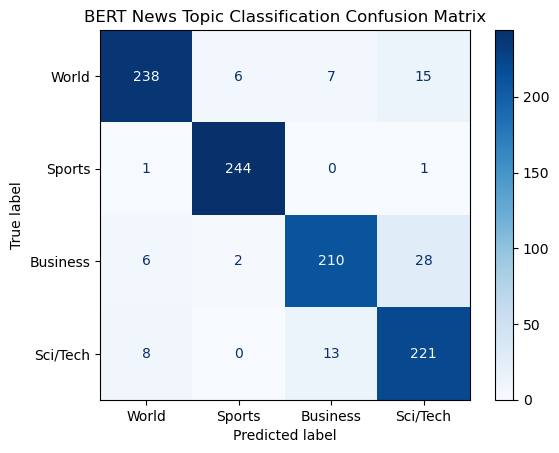

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "World",
        "Sports",
        "Business",
        "Sci/Tech"
    ]
)

disp.plot(cmap="Blues")

plt.title("BERT News Topic Classification Confusion Matrix")

plt.show()

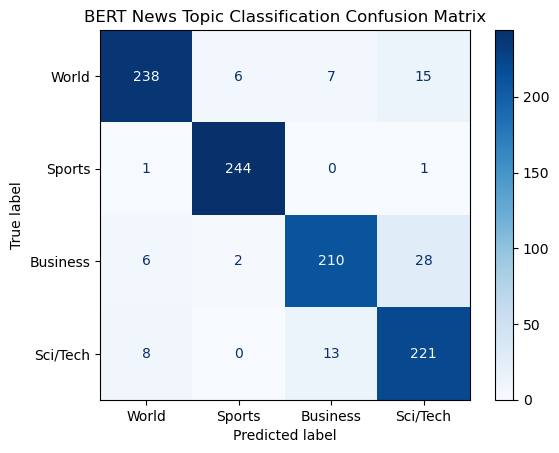

In [54]:
disp.plot(cmap="Blues")

plt.title("BERT News Topic Classification Confusion Matrix")

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [55]:
id2label = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

for i in range(5):
    print("=" * 80)
    print("News:")
    print(small_test[i]["text"])
    print()
    print("Actual:", id2label[y_true[i]])
    print("Predicted:", id2label[y_pred[i]])

News:
Indian board plans own telecast of Australia series The Indian cricket board said on Wednesday it was making arrangements on its own to broadcast next month #39;s test series against Australia, which is under threat because of a raging TV rights dispute.

Actual: Sports
Predicted: Sports
News:
Stocks Higher on Drop in Jobless Claims A sharp drop in initial unemployment claims and bullish forecasts from Nokia and Texas Instruments sent stocks slightly higher in early trading Thursday.

Actual: Business
Predicted: Business
News:
Nuggets 112, Raptors 106 Carmelo Anthony scored 30 points and Kenyon Martin added 24 points and 16 rebounds, helping the Denver Nuggets hold off the Toronto Raptors 112-106 Wednesday night.

Actual: Sports
Predicted: Sports
News:
Stocks Higher on Drop in Jobless Claims A sharp drop in initial unemployment claims and bullish forecasts from Nokia and Texas Instruments sent stocks higher in early trading Thursday.

Actual: Business
Predicted: Business
News:
RE

In [56]:
import pandas as pd

evaluation_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Weighted F1 Score"
    ],
    "Value": [
        accuracy,
        f1
    ]
})

evaluation_summary

,Metric,Value
0,Accuracy,0.913000
1,Weighted F1 Score,0.913055
